# Rossmann Store Sales — 02 · Exploratory Analysis

This notebook explores the clean table from `01_etl_pipeline` (about 1M daily rows across 1,115 stores). The project has a specific aim: build a model that forecasts a store's daily sales. So unlike a free exploration, I'm not looking at everything, I'm looking at the things that will tell me *how to build that model*, which features carry signal and which kind of model the data calls for.

Most of these questions came up while I was preparing the data in the ETL step. Writing them down here gives the notebook a clear goal, and I go through them one per section below. Each question is something I'm genuinely unsure about, the answers come from the data, not from me guessing ahead.

1. **Trend over time.** Is total sales growing, flat, or seasonal across the period the data covers? Is there an annual cycle (a December peak is the obvious guess)? And is there anything odd, gaps or level shifts, that I should be careful about before I trust this series for forecasting?

2. **Weekly pattern.** How do sales vary by day of the week? I expect some kind of weekly cycle (retail always has one), but I don't know its shape yet, whether it's a simple weekday-versus-weekend split, or something with more than one peak. The shape matters, because it decides how the weekday should be fed to a model.

3. **Do promotions actually lift sales, and by how much?** In the ETL, `Promo` was just a 0/1 flag whose meaning I hadn't tested. Here I want to see how big the lift is and how often promos run. A large, frequent effect is worth putting in the model; a tiny or rare one isn't.

4. **Does the promo lift depend on the weekday?** The single promo number from Question 3 is an average, and an average can hide structure. If the lift is large on some days and small on others, that's an *interaction*, and it's the one finding here that directly decides which kind of model I reach for in notebook 03 (a plain linear model can't represent an interaction, a tree can). So I've left it for last, since it ties the EDA to the modelling.

I go through them in order below, one section per question.

## Setup

Load the clean table and filter to open days. Closed days carry zero sales by definition (I confirmed that in the ETL), so leaving them in would drag every average down and invent a fake weekly dip on Sundays where stores are simply shut. Every question below is about *demand*, so it's about open days.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("data/rossmann_clean.parquet")
df["Date"] = pd.to_datetime(df["Date"])

open_df = df[df["Open"] == 1].copy()

# The forecast target is the daily TOTAL across open stores, so that's the series I explore.
daily_total = open_df.groupby("Date")["Sales"].sum()

print(f"all rows:  {len(df):,}")
print(f"open rows: {len(open_df):,} ({len(open_df)/len(df):.1%} of the data)")
print(f"average daily total (across open stores): {daily_total.mean():,.0f}")

all rows:  1,017,209
open rows: 844,392 (83.0% of the data)
average daily total (across open stores): 6,234,799


So I'm working with the open-day rows, and a typical open store does around the printed average in daily sales. That average is the yardstick for reading the charts below, a bar well above or below it is easy to judge against it.

## Question 1: Trend over time

First just to see the series. I aggregate to total daily sales across all open stores and plot it, this is the exact series I'll forecast in notebook 03, so I want its overall level and how noisy it is. The daily line is very busy though, so after it I aggregate to months, which makes the slower movements (any dip, any year-to-year difference) far easier to read than the daily noise allows.

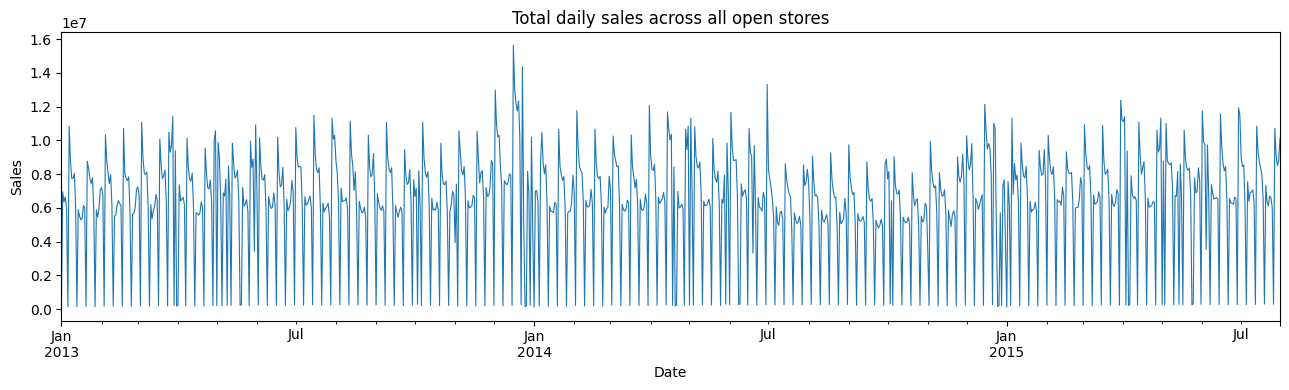

In [2]:
daily = open_df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(13, 4))
daily.plot(lw=0.8)
plt.title("Total daily sales across all open stores")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

The daily series oscillates hard, that dense up-and-down is the weekly cycle, which I look at in question 2. Beyond that, it's genuinely hard to read anything from this chart: the day-to-day swing is so large that a slower dip or a year-to-year shift is buried in the noise. This is exactly why a daily line is the wrong tool for the trend question. Aggregating to months below strips out the weekly cycle and lets the slower movements show.

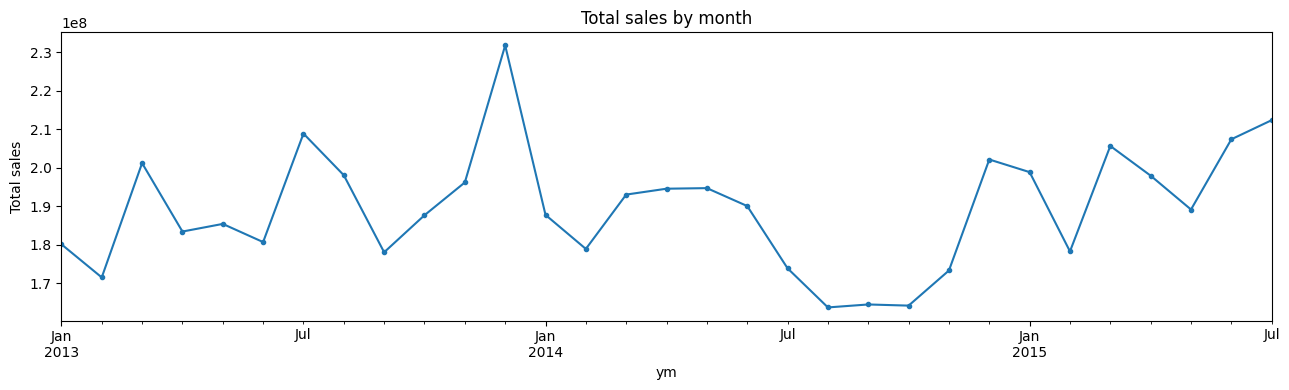

In [3]:
open_df["ym"] = open_df["Date"].dt.to_period("M")
monthly = open_df.groupby("ym").agg(
    total_sales=("Sales", "sum"),
    per_store=("Sales", "mean"),
    stores_reporting=("Store", "nunique"),
)

plt.figure(figsize=(13, 4))
monthly["total_sales"].plot(marker="o", ms=3)
plt.title("Total sales by month")
plt.ylabel("Total sales")
plt.tight_layout()
plt.show()

Now the slower change is easy to see. There is a clear dip in the second half of 2014. This dip can mean two very different things: either fewer stores are open and reporting, or the same stores are selling less. I need to know which one, because they matter differently for the forecast.

So next I check two things: the number of stores per month, and per-store sales for the same month in 2013 vs 2014.

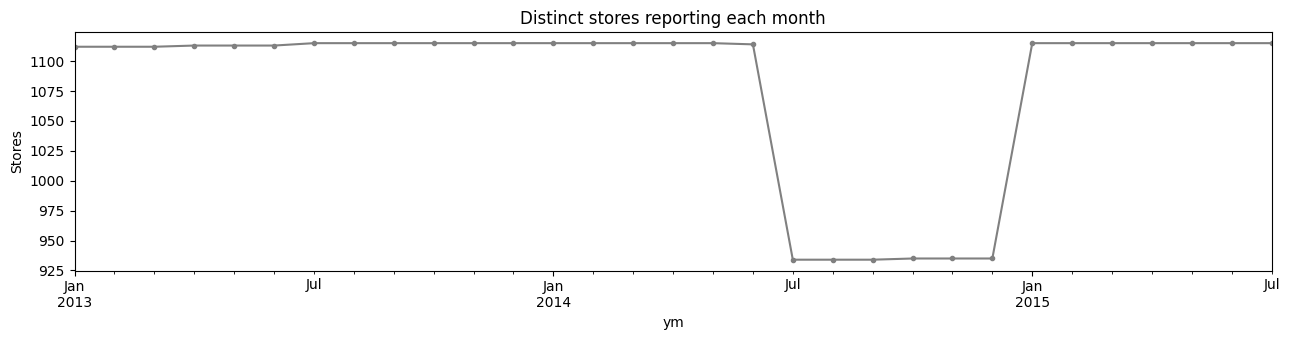

per-store sales, same month, 2013 (full coverage) vs 2014 (reduced coverage):
  Jul: 2013 6,923  ->  2014 6,891   (-0.5%)
  Aug: 2013 6,596  ->  2014 6,714   (+1.8%)
  Sep: 2013 6,363  ->  2014 6,757   (+6.2%)
  Oct: 2013 6,473  ->  2014 6,757   (+4.4%)
  Nov: 2013 6,905  ->  2014 7,540   (+9.2%)
  Dec: 2013 8,613  ->  2014 8,604   (-0.1%)


In [4]:
plt.figure(figsize=(13, 3.5))
monthly["stores_reporting"].plot(marker="o", ms=3, color="gray")
plt.title("Distinct stores reporting each month")
plt.ylabel("Stores")
plt.tight_layout()
plt.show()

# The reduced-coverage window is roughly H2-2014. Comparing its average to the overall
# average would be unfair, because that window includes December (the Christmas spike).
# The fair test is same-month vs same-month: H2-2014 (reduced) against H2-2013 (full coverage).
open_df["year"] = open_df["Date"].dt.year
open_df["month"] = open_df["Date"].dt.month
per_store_my = open_df.groupby(["month", "year"])["Sales"].mean().unstack("year")

reduced_months = [7, 8, 9, 10, 11, 12]
names_m = {7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
print("per-store sales, same month, 2013 (full coverage) vs 2014 (reduced coverage):")
for m in reduced_months:
    if 2013 in per_store_my.columns and 2014 in per_store_my.columns:
        a, b = per_store_my.loc[m, 2013], per_store_my.loc[m, 2014]
        print(f"  {names_m[m]}: 2013 {a:,.0f}  ->  2014 {b:,.0f}   ({(b/a-1)*100:+.1f}%)")

The store count drops from about 1,115 to about 935 in the second half of 2014. So part of the dip is just fewer stores. That is a coverage effect. But is it the whole story, or were the open stores also selling less?

To check fairly, I compare each month against the same month a year earlier (for example August 2014 vs August 2013). I avoid comparing to the yearly average, because this window includes December, and Christmas would push the average up for the wrong reason.

The result surprised me: 2014 is **not** lower. Four of the six months are actually higher than 2013 (Sep +6%, Oct +4%, Nov +9%), and the other two are almost flat. So per-store demand did not fall.

This makes the reading simple. The 2014 dip in total sales is only about coverage (fewer stores), not weaker demand.

**What I will forecast, and why total, not per store.** This is also where I decide the forecast target for notebook 03. I forecast the *total* daily sales, not the average per store. The two agree most of the time, but they disagree exactly when the number of open stores moves, and that difference matters. The clearest case is Sunday: almost all stores close, so *average per store* makes Sunday look like the best day of the week, when for the business it is one of the lowest, the average is only high because a few open stores serve everyone. Forecasting the total avoids this trap and answers the real question (how much money comes in that day), instead of mistaking "fewer stores open" for "more demand". The cost is that the total moves with how many stores are open, which is why the 2014 window still needs care: I keep the chronological split and lean on the full-coverage periods, rather than reading the 2014 dip as either pure coverage or a real fall.

One more thing worth checking before trusting this for forecasting: **is the seasonal shape stable across years**, or does it wander? If March is strong one year and weak the next, a model can't rely on the calendar. I plot total sales by month, one line per year, so the years sit on top of each other.

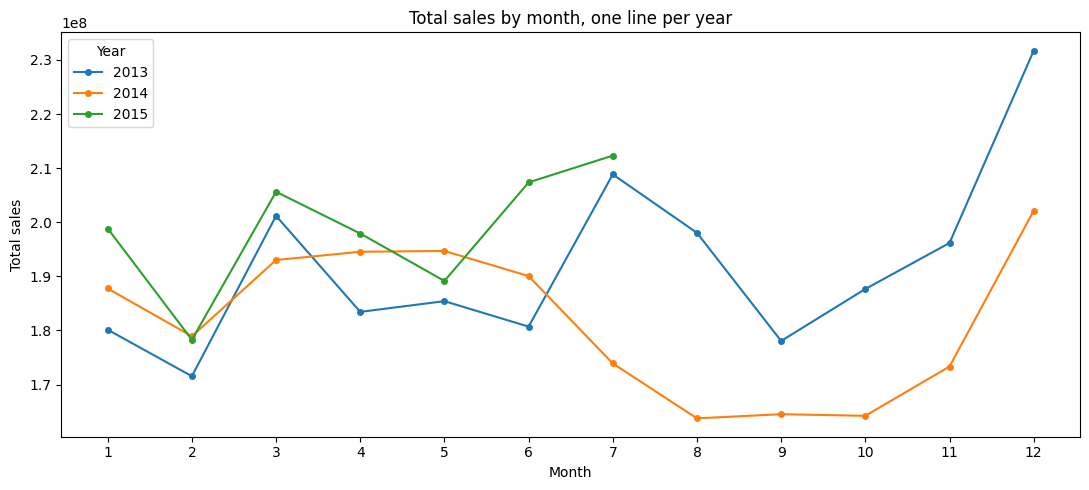

2013: Jan-Nov sits in 171,534,275-208,843,882 (a 22% band); December 231,710,561 = +23% above it
2014: Jan-Nov sits in 163,748,475-194,693,257 (a 19% band); December 202,120,592 = +12% above it


In [13]:
open_df["year"]  = open_df["Date"].dt.year
open_df["month"] = open_df["Date"].dt.month

# Monthly total sales (sum across the month), one line per year.
yoy = open_df.groupby(["year", "month"])["Sales"].sum().unstack(0)

plt.figure(figsize=(11, 5))
for year in yoy.columns:
    plt.plot(yoy.index, yoy[year], marker="o", ms=4, label=str(year))
plt.title("Total sales by month, one line per year")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# how big is December vs the rest of the year?
full_years = [y for y in yoy.columns if yoy[y].notna().all()]

for y in full_years:
    col = yoy[y]
    jan_nov = col.loc[1:11]
    print(f"{y}: Jan-Nov sits in {jan_nov.min():,.0f}-{jan_nov.max():,.0f} "
          f"(a {(jan_nov.max()/jan_nov.min()-1)*100:.0f}% band); "
          f"December {col.loc[12]:,.0f} = {(col.loc[12]/jan_nov.mean()-1)*100:+.0f}% above it")

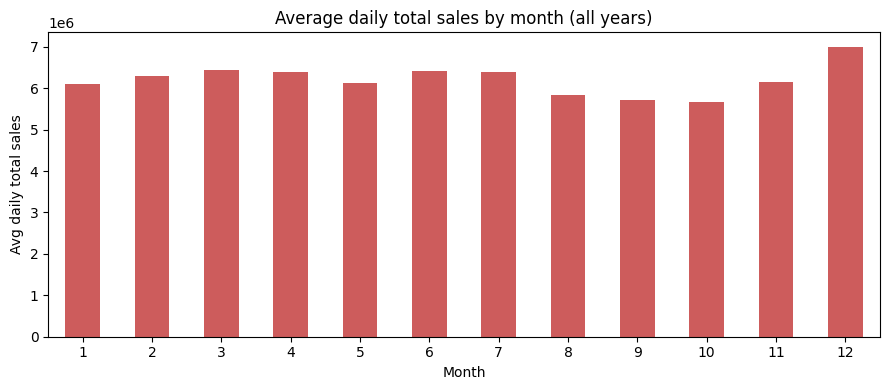

December vs the yearly average: +12.6%
top 3 months:
  month 12: 6,997,277
  month  3: 6,449,805
  month  6: 6,423,475
the three effects (note: promo is per-store, the others are daily totals):
  weekday: Monday is ~17% above the Mon-Sat norm (plus a Sunday collapse)
  promo lift (per store): ~39%
  December vs yearly average: ~13%


In [22]:
# All years combined: the flat-except-December shape, in daily-total terms.
daily_total_df = daily_total.rename("y").reset_index()
daily_total_df["Month"] = daily_total_df["Date"].dt.month
monthly_avg = daily_total_df.groupby("Month")["y"].mean()

plt.figure(figsize=(9, 4))
monthly_avg.plot(kind="bar", color="indianred")
plt.title("Average daily total sales by month (all years)")
plt.xlabel("Month")
plt.ylabel("Avg daily total sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dec_effect = (monthly_avg[12] / monthly_avg.mean() - 1) * 100
print(f"December vs the yearly average: {dec_effect:+.1f}%")
print("top 3 months:")
for m, v in monthly_avg.sort_values(ascending=False).head(3).items():
    print(f"  month {m:2d}: {v:,.0f}")

There is a yearly pattern, but it lives mostly in one place: December. The all-years bar chart shows December sitting clearly above every other month (+12.6% above the yearly average), while the rest of the year is fairly flat, from a late-summer low (around August–October) up through a mild rise into the autumn. So December is the one calendar effect worth counting on.

The year-over-year chart (one line per year) tells the same story and adds a caution. December is the peak in every full year (about +23% above the Jan–Nov average in 2013, +12% in 2014). But the second half of 2014 sits visibly below the other years: that is the coverage dip from earlier, fewer stores reporting, showing up in the totals. It is not a change in demand, so I don't read it as a trend.

This answers a feature question for notebook 03: should I add a `lag_365` feature (sales one year ago)? No, for two reasons. First, the yearly pattern is weak: only December really repeats, and a month feature can capture that. Second, I only have 2.5 years of data, too short for a one-year lag to be useful. So a `month` feature (as separate categories, not the integer 1–12) is enough for the yearly signal, and I don't expect it to do heavy work.

## Question 2: Weekly pattern

The daily series oscillated hard, so now I want the shape of that weekly cycle: which days are strong, which are weak, and whether it's a simple slope or something with more than one peak. I average sales per weekday. I'll also count how many stores open each day, because an average taken over a few hundred stores has to be read differently from one taken over a thousand.

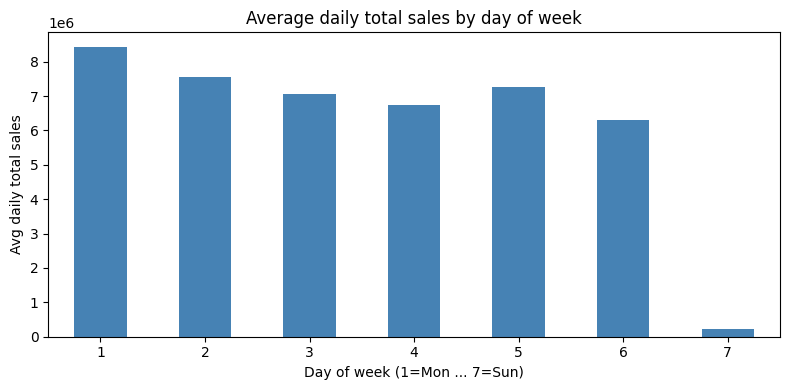

average daily total by weekday:
  Mon: 8,434,351
  Tue: 7,558,607
  Wed: 7,073,799
  Thu: 6,749,465
  Fri: 7,263,377
  Sat: 6,315,804
  Sun: 220,533

Sunday: 220,533 (a near-zero trough, only a handful of stores open)
Mon (peak) vs Sat (weekday low): 34% higher
Mon vs the Mon-Sat average: 17% above the working-week norm
highest: Mon   lowest: Sun

open-store count per weekday (why Sunday is low):
  Mon: 137,560
  Tue: 143,961
  Wed: 141,936
  Thu: 134,644
  Fri: 138,640
  Sat: 144,058
  Sun: 3,593


In [21]:
# Weekly shape in daily-total terms (what the model forecasts).
daily_total_df["DayOfWeek"] = daily_total_df["Date"].dt.dayofweek + 1  # 1=Mon ... 7=Sun
dow = daily_total_df.groupby("DayOfWeek")["y"].mean()

plt.figure(figsize=(8, 4))
dow.plot(kind="bar", color="steelblue")
plt.title("Average daily total sales by day of week")
plt.xlabel("Day of week (1=Mon ... 7=Sun)")
plt.ylabel("Avg daily total sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

names = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
print("average daily total by weekday:")
for d, v in dow.items():
    print(f"  {names[d]}: {v:,.0f}")

# Sunday is a near-zero special case (almost all stores shut), so a raw max/min
# "swing" is dominated by it. Report two honest numbers instead:
workdays = dow.loc[1:6]  # Mon..Sat
print(f"\nSunday: {dow.loc[7]:,.0f} (a near-zero trough, only a handful of stores open)")
print(f"Mon (peak) vs Sat (weekday low): {(dow.loc[1]/dow.loc[6]-1)*100:.0f}% higher")
print(f"Mon vs the Mon-Sat average: {(dow.loc[1]/workdays.mean()-1)*100:.0f}% above the working-week norm")
print(f"highest: {names[dow.idxmax()]}   lowest: {names[dow.idxmin()]}")

print("\nopen-store count per weekday (why Sunday is low):")
for d, v in open_df["DayOfWeek"].value_counts().sort_index().items():
    print(f"  {names[d]}: {v:,}")

This is more interesting than just "which day is busiest".

Monday is the clear peak (~8.4M), then the working week steps down gently through to Saturday, with a small Friday bump. Sunday is not a peak at all, it collapses to almost nothing (~0.2M). This ties straight back to the coverage section: almost all German stores close on Sunday (only ~3,600 open, against ~140,000 on weekdays), so the total business does almost no trade that day. The few open stores each sell a lot, but the total is tiny. Since I forecast the total, Sunday is the low point of the week.

Because Sunday is a near-zero closure artifact, a raw "best vs worst day" swing is dominated by it and not meaningful. The honest read of the working week is that Monday sits about 17% above the Monday-to-Saturday average, with the rest of the week fairly flat below it, plus the separate Sunday collapse.

This decides how weekday enters the model. I feed it as separate categories, not the integer 1–7: the Sunday cliff is a discontinuity no single straight-line slope through 1–7 could represent. A `lag_7` feature (same weekday last week) also captures this shape automatically, which is why I lean on it in notebook 03.

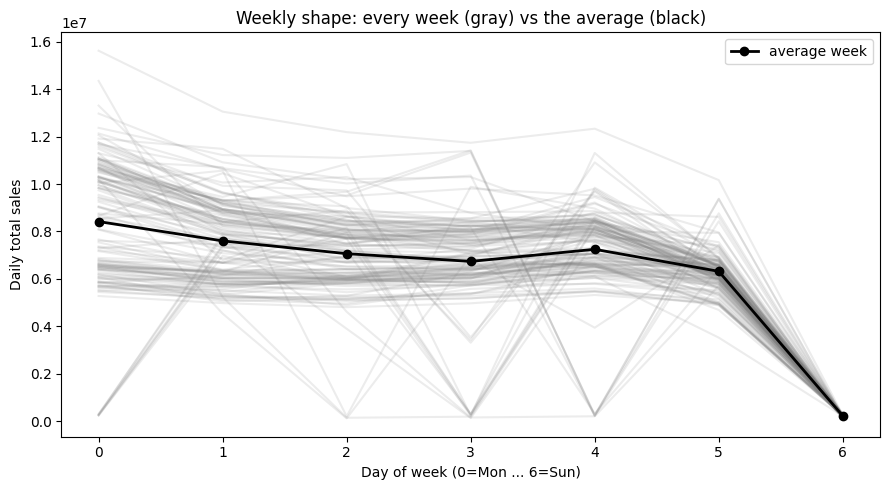

weeks compared: 133
median week-to-average shape correlation: 0.97
share of weeks with correlation > 0.9: 76%


In [16]:
# Each week's shape, in daily totals, vs the average week.
wk = daily_total.rename("y").reset_index()
wk["dow"]  = wk["Date"].dt.dayofweek
wk["week"] = wk["Date"].dt.isocalendar().week
wk["yr"]   = wk["Date"].dt.isocalendar().year
pivot = wk.pivot_table(index=["yr", "week"], columns="dow", values="y")
pivot = pivot.dropna()  # keep only full weeks

avg_shape = pivot.mean(axis=0)

plt.figure(figsize=(9, 5))
for _, row in pivot.iterrows():
    plt.plot(range(7), row.values, color="gray", alpha=0.15)
plt.plot(range(7), avg_shape.values, color="black", lw=2, marker="o", label="average week")
plt.title("Weekly shape: every week (gray) vs the average (black)")
plt.xlabel("Day of week (0=Mon ... 6=Sun)")
plt.ylabel("Daily total sales")
plt.legend()
plt.tight_layout()
plt.show()

corrs = pivot.apply(lambda r: pd.Series(r.values).corr(pd.Series(avg_shape.values)), axis=1)
print(f"weeks compared: {len(corrs)}")
print(f"median week-to-average shape correlation: {corrs.median():.2f}")
print(f"share of weeks with correlation > 0.9: {(corrs > 0.9).mean()*100:.0f}%")

The shape repeats, and quite strongly. Each faint line is one week. Most weeks hug the black average closely: the median week matches the average shape at about 0.97 correlation, and about 76% of weeks match it closely (above 0.9). A big part of that consistency is the Sunday collapse, which happens every single week and anchors the shape, so week-to-week the profile is very stable.

This makes the weekly cycle the backbone pattern for the model. It is why `lag_7` (the same weekday last week) is a strong feature: last week's Monday predicts this week's Monday well. It is not perfect, the working-week days still wobble from week to week, so the model wants the lag plus other features, not the lag alone. Compared to the yearly pattern (flat outside December), the weekly cycle is both bigger and more reliable, so it is what the forecast is built around.

## Question 3: Do promotions lift sales, and by how much?

In the ETL I treated `Promo` as just a 0/1 flag and deliberately didn't claim it did anything. Now I test it. Two things decide whether it belongs in the model: how big the lift is, and how often promos actually run. A big effect that happens all the time is worth modelling; a small or rare one isn't.

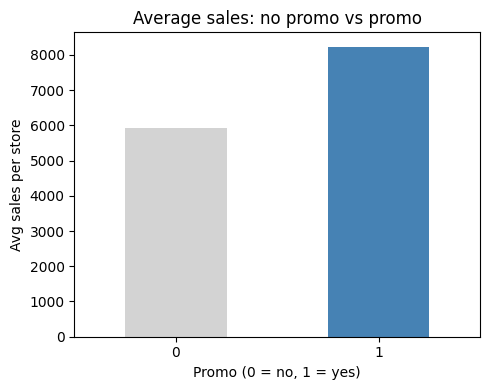

avg sales without promo: 5,929
avg sales with promo:    8,228
promo lift: +38.8%
share of open days with a promo: 44.6%


In [24]:
promo_means = open_df.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(5, 4))
promo_means.plot(kind="bar", color=["lightgray", "steelblue"])
plt.title("Average sales: no promo vs promo")
plt.xlabel("Promo (0 = no, 1 = yes)")
plt.ylabel("Avg sales per store")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

lift = (promo_means[1] / promo_means[0] - 1) * 100
print(f"avg sales without promo: {promo_means[0]:,.0f}")
print(f"avg sales with promo:    {promo_means[1]:,.0f}")
print(f"promo lift: {lift:+.1f}%")
print(f"share of open days with a promo: {open_df['Promo'].mean():.1%}")



Both questions answered. The lift is large (see the printed percentage): sales jump clearly on promo days. So `Promo` marks something real, which I was careful not to assume in the ETL. And promos run on about half of all open days, so this is not rare, it is a normal part of the business.

Large and frequent means `Promo` belongs in the model. Leaving it out would turn all that variation into noise. It is also useful in practice: once the model knows the promo effect, a planner can compare a promo day against a non-promo day before deciding to run a campaign.

## Question 4: Does the promo lift depend on the weekday?

The single promo number from Question 3 is an average over all days, and an average can hide structure. A lift that's big on Mondays and small on Fridays would average out to something moderate, and a model that only knew the average would be wrong at both ends. This is the finding that decides which kind of model I reach for in notebook 03, so it's worth doing carefully. I break the lift down day by day.

In [10]:
pivot = open_df.pivot_table(index="DayOfWeek", columns="Promo", values="Sales", aggfunc="mean")
pivot.columns = ["no_promo", "promo"]
pivot["lift_%"] = ((pivot["promo"] / pivot["no_promo"] - 1) * 100).round(1)
pivot.index = [names[d] for d in pivot.index]

print("average sales with and without promo, by weekday:")
print(pivot.round(0))

average sales with and without promo, by weekday:
     no_promo   promo  lift_%
Mon    6223.0  9773.0    57.0
Tue    5716.0  8277.0    45.0
Wed    5617.0  7685.0    37.0
Thu    5750.0  7598.0    32.0
Fri    6344.0  7744.0    22.0
Sat    5875.0     NaN     NaN
Sun    8225.0     NaN     NaN


This is the most important finding in the notebook.

The promo lift is not constant, it falls across the week. Reading the `lift_%` column from Monday down, the lift is strongest early in the week and weakest by Friday, dropping by more than half from one end to the other. The same promo does much more on a Monday than on a Friday.

Saturday and Sunday are blank in the promo column. That is not missing data: promos never run on weekends in this dataset, so there is nothing to compare.

So promo and weekday interact strongly, and this decides the model. A plain linear model can learn "promo adds X" and "Monday adds Y", but it cannot learn "promo adds a lot on Monday and little on Friday". It is stuck with one average promo effect and will be wrong at both ends of the week. A tree model learns this interaction naturally, because it can split on weekday first and then on promo.

So notebook 03 should compare a linear model against a tree ensemble. Based on this table, I expect the tree to win. But I will run both and let the holdout data decide, not just assume it.

In [25]:
# Three effects, but each in honest units:
# - weekday: Monday vs the Mon-Sat norm (Sunday excluded as a closure artifact)
# - promo: per-store lift (a per-store treatment, kept per-store on purpose)
# - December: total daily sales vs yearly average
weekday_effect = (dow.loc[1] / dow.loc[1:6].mean() - 1) * 100
promo_effect   = (promo_means[1] / promo_means[0] - 1) * 100   # per-store, from the promo cell
print("the three effects (note: promo is per-store, the others are daily totals):")
print(f"  weekday: Monday is ~{weekday_effect:.0f}% above the Mon-Sat norm (plus a Sunday collapse)")
print(f"  promo lift (per store): ~{promo_effect:.0f}%")
print(f"  December vs yearly average: ~{dec_effect:.0f}%")

the three effects (note: promo is per-store, the others are daily totals):
  weekday: Monday is ~17% above the Mon-Sat norm (plus a Sunday collapse)
  promo lift (per store): ~39%
  December vs yearly average: ~13%


## What this means for the model

Pulling the four answers together, each maps to a decision for notebook 03. The percentages here are the ones printed by the cells, so this always matches the run.

| Finding | What it means for the model |
|---|---|
| Weekly cycle is the biggest pattern: Monday peak, a gently declining working week, and a Sunday collapse (almost all stores shut) | Feed weekday as separate categories, not an integer; the Sunday cliff is a discontinuity a straight line can't fit. `lag_7` captures the shape automatically. |
| Promotions lift sales a lot (~39% per store), on about half of open days | Include `Promo` as a feature; also lets me forecast promo vs no-promo scenarios. |
| Promo lift interacts with weekday (strong early week, weak Friday; none on weekends) | Compare a linear model against a tree ensemble, trees can learn this interaction, linear models can't. I expect the tree to win. |
| December peak (~13% above the yearly average), otherwise fairly flat | Include a `month` feature (as categories), but it's a refinement, not a main driver. |
| Weekly shape is strong and stable (median week matches the average at ~0.97, ~76% of weeks above 0.9), largely anchored by the Sunday collapse | `lag_7` is the backbone feature (last week's weekday predicts this week's), strong but not exact, so pair it with other features. |
| 2014 dip is a coverage effect (fewer stores reporting), not a demand change | No special fix needed; keep the chronological split, and no `lag_365`. |
| Closed days are structural zeros | Forecast open days only. |